# Final USD/LKR Exchange Rate Prediction

## 1. Introduction

This notebook generates a final USD/LKR exchange rate forecast using the best-performing model identified during the model evaluation stage.

Based on the current model comparison, the Naive model achieved the lowest Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The Naive forecasting method assumes that the next observed exchange rate will be equal to the most recently observed exchange rate.

This notebook will:
- Load the exchange rate dataset.
- Identify the date and latest observed exchange rate.
- Generate a one-step-ahead forecast.
- Save the prediction and its date.
- Visualize the recent exchange rates and forecast.
- Summarize the final prediction.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset

The processed master dataset is loaded for the final prediction. The dataset should contain the USD/LKR exchange rate and its corresponding observation date.

In [6]:
# Load the processed dataset
df = pd.read_csv("../data/processed/master_dataset.csv")

# Display column names
print("Dataset columns:")
print(df.columns.tolist())

# Display the first five rows
df.head()

Dataset columns:
['date', 'USD_LKR']


,date,USD_LKR
0,2010-05-07,113.6975
1,2010-05-11,113.6292
2,2010-05-12,113.6854
3,2010-05-13,113.7009
4,2010-05-14,113.6573


## 3. Prepare the Data

The date column is converted to datetime format, and the data is sorted chronologically. Rows without a valid exchange rate or date are excluded from the final prediction process.

In [10]:
# Convert the date column to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Convert exchange rates to numeric values
df["USD_LKR"] = pd.to_numeric(df["USD_LKR"], errors="coerce")

# Remove rows with missing dates or exchange rates
valid_data = df.dropna(subset=["date", "USD_LKR"]).copy()

# Sort observations by date
valid_data = valid_data.sort_values("date").reset_index(drop=True)

# Display the latest five observations
valid_data[["date", "USD_LKR"]].tail()

,date,USD_LKR
3494,2026-09-21,330.3490
3495,2026-09-22,330.8125
3496,2026-09-23,329.8867
3497,2026-09-24,329.0158
3498,2026-09-25,330.3522


## 4. Identify the Latest Observation

The most recent valid exchange rate observation is selected from the dataset. Its date and exchange rate will be used to generate the Naive forecast.

In [12]:
# Get the latest observed row
latest_row = valid_data.iloc[-1]

latest_date = latest_row["date"]
latest_rate = latest_row["USD_LKR"]

print("Latest observation date:", latest_date.date())
print("Latest observed USD/LKR rate:", latest_rate)

Latest observation date: 2026-09-25
Latest observed USD/LKR rate: 330.3522


## 5. Generate the Final Prediction

The Naive forecasting model assumes that the next exchange rate observation will be equal to the latest observed exchange rate.

Forecast = Latest Observed Exchange Rate

The forecast is a one-step-ahead prediction. The next observation date will be determined separately because the dataset may follow a business-day calendar.

In [13]:
# Generate the Naive forecast
naive_prediction = latest_rate

print("Latest observation date:", latest_date.date())
print("Latest observed USD/LKR rate:", latest_rate)
print("Predicted next USD/LKR rate:", naive_prediction)

Latest observation date: 2026-09-25
Latest observed USD/LKR rate: 330.3522
Predicted next USD/LKR rate: 330.3522


## 6. Create the Prediction Results Table

The latest observed date, latest exchange rate, predicted rate, and selected model are combined into a single table.

In [14]:
# Create the final prediction table
prediction_result = pd.DataFrame({
    "Latest_Observation_Date": [latest_date],
    "Latest_Observed_Rate": [latest_rate],
    "Predicted_Next_Rate": [naive_prediction],
    "Model": ["Naive"]
})

prediction_result

,Latest_Observation_Date,Latest_Observed_Rate,Predicted_Next_Rate,Model
0,2026-09-25,330.3522,330.3522,Naive


## 7. Save the Final Prediction

The final prediction results are saved as a CSV file in the processed data folder for future reference and reporting.

In [15]:
# Save the prediction results
prediction_result.to_csv(
    "../data/processed/final_forecast.csv",
    index=False
)

print("Final prediction saved successfully.")

Final prediction saved successfully.


## 8. Visualize the Recent Exchange Rates

A line graph displays the 30 most recent observed USD/LKR exchange rates. The Naive forecast is marked separately. Since the forecast equals the latest observed rate, its marker is placed at the latest observation date for illustration.

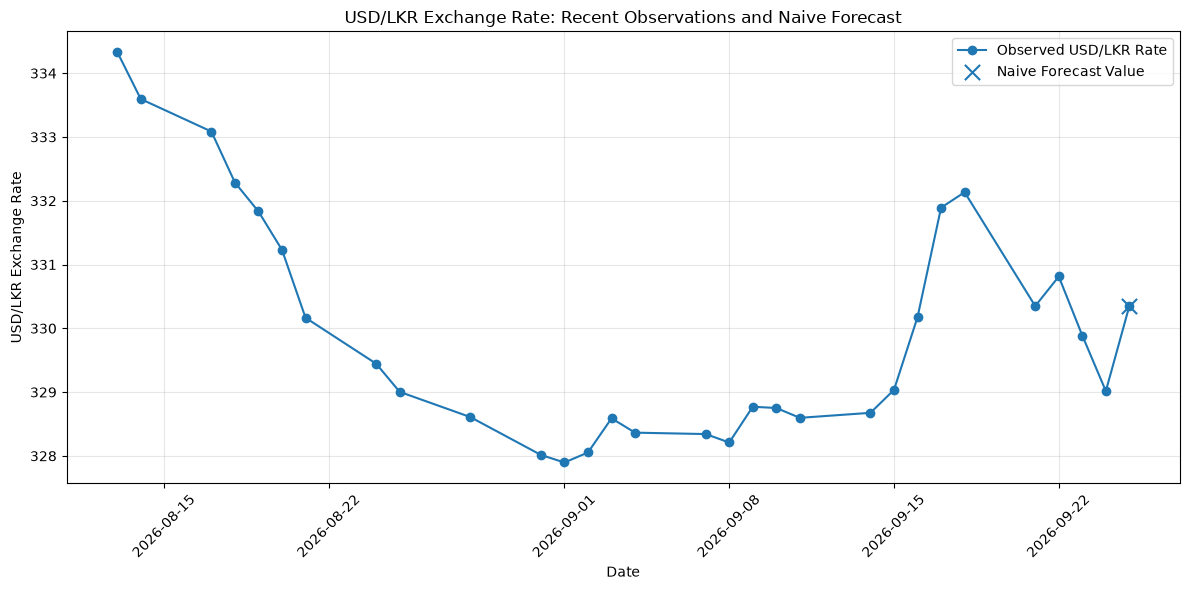

In [16]:
# Select the latest 30 observations
recent_data = valid_data.tail(30).copy()

plt.figure(figsize=(12, 6))

# Plot the observed exchange rates
plt.plot(
    recent_data["date"],
    recent_data["USD_LKR"],
    marker="o",
    label="Observed USD/LKR Rate"
)

# Mark the Naive forecast value
plt.scatter(
    [latest_date],
    [naive_prediction],
    marker="x",
    s=120,
    label="Naive Forecast Value"
)

plt.title("USD/LKR Exchange Rate: Recent Observations and Naive Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Conclusion

The Naive model achieved the lowest MAE and RMSE in the current model comparison and was therefore selected for the final prediction demonstration.

The model uses the most recently observed USD/LKR exchange rate as the forecast for the next observation. This provides a simple baseline for exchange-rate forecasting, although it does not capture future trends or unexpected market movements.

The forecast should be interpreted as a one-step-ahead prediction rather than a long-term exchange-rate forecast. Its performance should be assessed against actual future observations when they become available.